In [10]:
import numpy as np
from scipy.stats import poisson
from scipy.optimize import Bounds, minimize, minimize_scalar
from itertools import permutations
from utilities import adaptive_util, nonadaptive_util, adaptivity_gap
from tqdm.notebook import tqdm

import plotnine
from plotnine import (
    ggplot,
    aes, 
    geom_point, 
    geom_raster, 
    scale_x_continuous, 
    scale_y_continuous, 
    geom_abline, geom_vline, 
    geom_tile,
    geom_polygon, theme_void,
    labs
)
import pandas as pd

In [2]:
n: int = 10
k: int = int(0.8 * n)

# 3 Parameter Setting

In [5]:
grid = []
step = 0.01
for a in tqdm(np.arange(0.0, 1.01, step)):
    row = []
    for b in np.arange(0.0, 1.01, step):
        c = 1 - a - b
        if c < 0:
            gap = np.nan 
        else:
            gap = adaptivity_gap(n, k, [a,b,c])
        row.append(gap)
    grid.append(row)

  0%|          | 0/101 [00:00<?, ?it/s]

In [6]:
grid_df = pd.DataFrame(grid).melt()
grid_df.columns = ['p_1', 'Gap']
grid_df.insert(1,'p_2',grid_df.index%len(grid))
grid_df

,p_1,p_2,Gap
0,0,0,1.0
1,0,1,1.0
2,0,2,1.0
3,0,3,1.0
4,0,4,1.0
...,...,...,...
10196,100,96,NaN
10197,100,97,NaN
10198,100,98,NaN
10199,100,99,NaN


In [7]:
grid_df2 = grid_df.copy()
grid_df2['p_3'] = 100 - grid_df2.p_1 - grid_df2.p_2
grid_df2.p_1 = grid_df2.p_1 / 100
grid_df2.p_2 = grid_df2.p_2 / 100
grid_df2.p_3 = grid_df2.p_3 / 100
grid_df2 = grid_df2[grid_df2.p_3 > 0.001]

In [8]:
norm_vec = [1,1,1]
e1 = [-np.sqrt(2)/2,np.sqrt(2)/2,0]
e2 = [-np.sqrt(3)/2,-np.sqrt(3)/2,np.sqrt(3)/2]

In [9]:
grid_df2['proj_x'] = grid_df2[['p_1','p_2','p_3']].dot(e1)
grid_df2['proj_y'] = grid_df2[['p_1','p_2','p_3']].dot(e2)

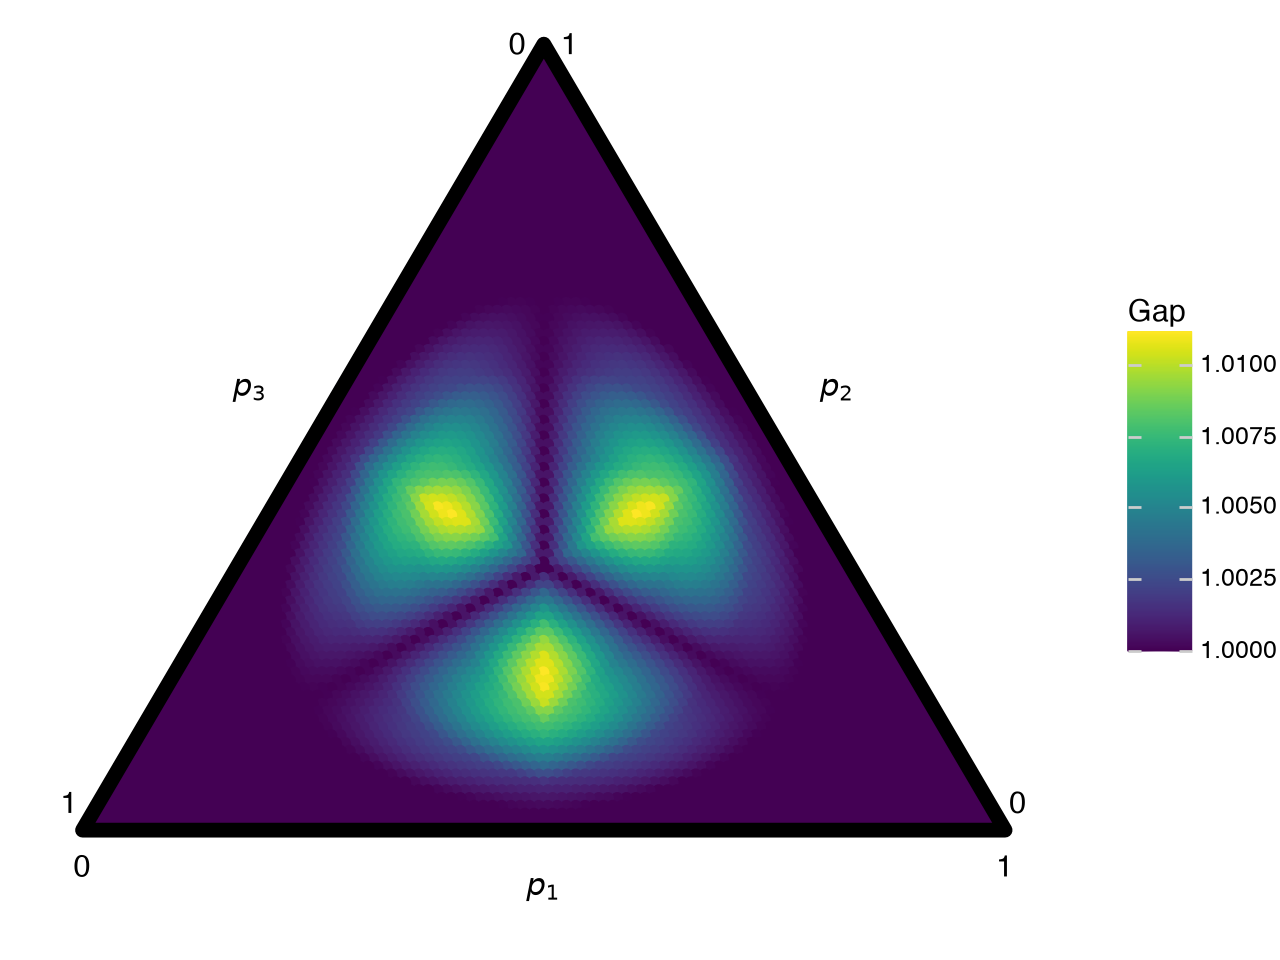

In [10]:
triangle = pd.DataFrame([[-np.sqrt(2)/2,-np.sqrt(3)/2],[np.sqrt(2)/2,-np.sqrt(3)/2],[0,np.sqrt(3)/2]], columns=['x','y'])
(
    ggplot(grid_df2, aes('proj_x','proj_y', fill='Gap')) 
    + geom_point(size=2.5, stroke=0)
    + theme_void()
    + geom_polygon(data=triangle, mapping=aes('x','y'), colour='black', fill=None, size=3)
    + plotnine.xlim(-np.sqrt(2)/2-.05,np.sqrt(2)/2+.05)
    + plotnine.ylim(-np.sqrt(2)/2-.35,np.sqrt(3)/2+.0)
    + plotnine.annotate('text', x=0, y=-1.0, label='$p_1$')
    + plotnine.annotate('text', x=0.45, y=0.1, label='$p_2$')
    + plotnine.annotate('text', x=-0.45, y=0.1, label='$p_3$')
    + plotnine.annotate('text', x=-np.sqrt(2)/2, y=-np.sqrt(3)/2 - 0.08, label='0')
    + plotnine.annotate('text', x=np.sqrt(2)/2, y=-np.sqrt(3)/2 - 0.08, label='1')
    + plotnine.annotate('text', x=np.sqrt(2)/2 + 0.02, y=-np.sqrt(3)/2 + 0.06, label='0')
    + plotnine.annotate('text', 0.04, y=np.sqrt(3)/2, label='1')
    + plotnine.annotate('text', -0.04, y=np.sqrt(3)/2, label='0')
    + plotnine.annotate('text', x=-np.sqrt(2)/2 - 0.02, y=-np.sqrt(3)/2 + 0.06, label='1')
)

In [11]:
grid_df2[grid_df2.Gap == grid_df2.Gap.max()]

,p_1,p_2,Gap,p_3,proj_x,proj_y
4060,0.4,0.2,1.01115,0.4,-1.414214e-01,-0.173205
4080,0.4,0.4,1.01115,0.2,-1.760577e-17,-0.519615


In [12]:
max(list(grid_df2.Gap))

1.0111497061574861

# Single Parameter Setting

In [3]:
table = []
for n in tqdm(range(10, 51)):
    row = []
    for i in np.arange(0.34, 0.5, 0.01):
        row.append(adaptivity_gap(n,int(0.8*n),[i,i,1-2*i]))
    table.append(row)

  0%|          | 0/41 [00:00<?, ?it/s]

In [5]:
df = pd.DataFrame(table, columns=[f'{i:0.2f}' for i in np.arange(0.34,0.5, 0.01)])
data = pd.DataFrame(df.stack()).reset_index()
# data = data[data.i <= 10]
# data.columns = ['Gap']
# data['i'] = [data.index[i][0] for i in range(len(data))]
data.columns = ['i', 'epsilon', 'gap']
data.i = (data.i + 5)
data.i = data.i.astype(str)
data.epsilon = (data.epsilon.astype(float) * 100).round()

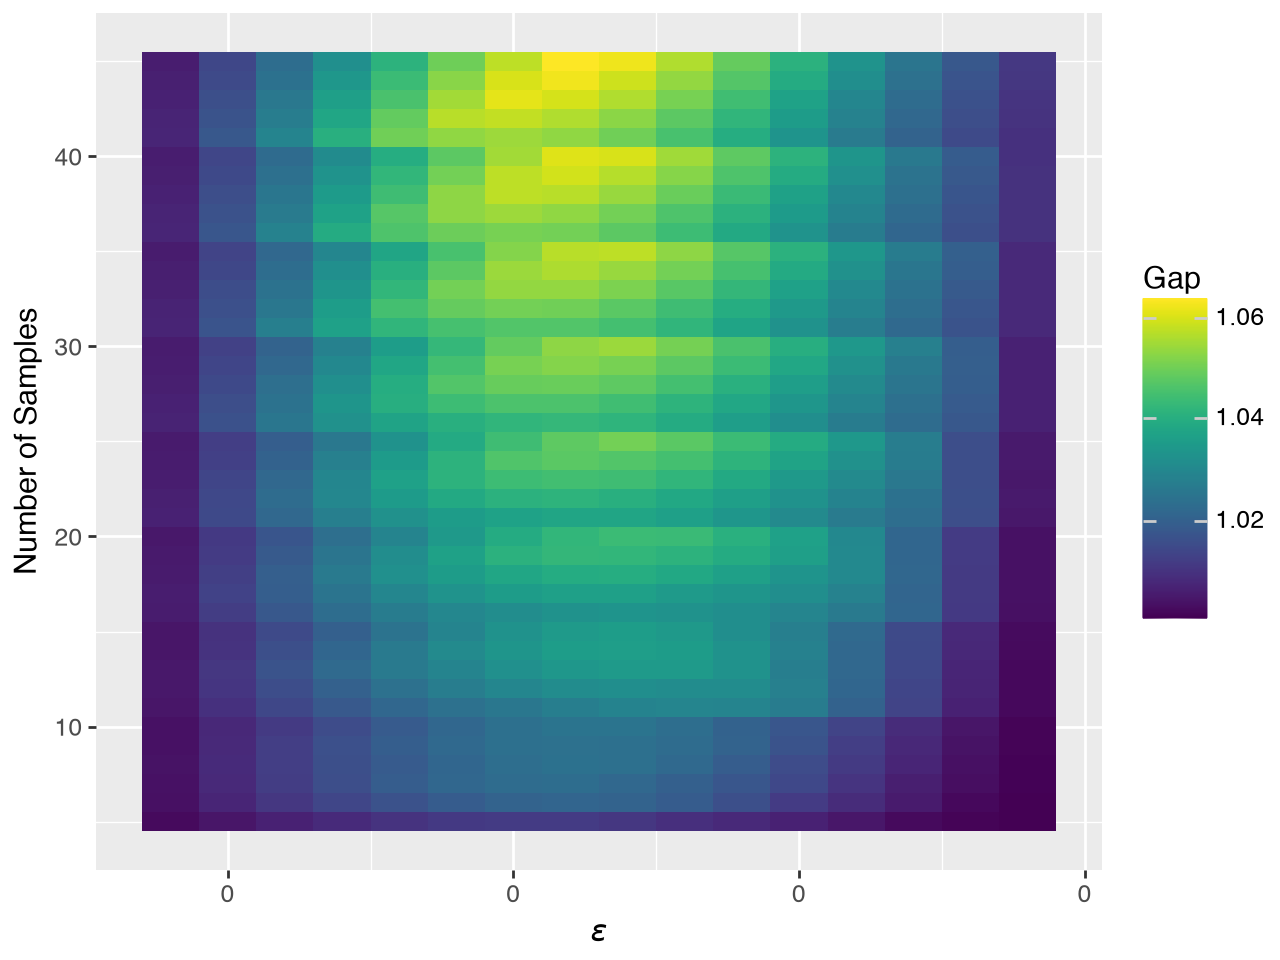

In [14]:
data.i = data.i.astype(int)
data.epsilon = (data.epsilon.astype(float) / 100)
(
    ggplot(data, aes(x='epsilon',y='i'))
    + geom_raster(aes(fill='gap'))
    + labs(
        x = r'$\epsilon$',
        y = 'Number of Samples',
        fill='Gap'
    )
)

In [17]:
data.gap.max()

np.float64(1.064083045299671)